<a href="https://colab.research.google.com/github/mamun-career-tech/Banking_Fraud_Detection_DeepLearning-MachineLearning/blob/main/V2_Banking_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title Install packages
# If you hit version conflicts, restart runtime (Runtime -> Restart runtime) and re-run.

!pip -q install -U "scikit-learn>=1.3" "pandas>=2.0" "numpy>=1.24" "matplotlib>=3.7" "seaborn>=0.13" \
    "imbalanced-learn>=0.11" "xgboost>=2.0" "lightgbm>=4.0" \
    "optuna>=3.6" "shap>=0.44" "lime>=0.2.0.1" \
    "joblib>=1.3" "tqdm>=4.66" "scipy>=1.10"

import sys, platform, os, random, time, json, re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from importlib import metadata

def show_versions(packages):
    versions = {}
    for p in packages:
        try:
            versions[p] = metadata.version(p)
        except metadata.PackageNotFoundError:
            versions[p] = None
    return versions

packages_to_log = [
    "numpy", "pandas", "scikit-learn", "imbalanced-learn",
    "xgboost", "lightgbm", "optuna", "shap", "lime",
    "matplotlib", "seaborn", "scipy", "joblib"
]
print("Python:", sys.version)
print("Platform:", platform.platform())
print("Package versions:\n", json.dumps(show_versions(packages_to_log), indent=2))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 14.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 wh

In [ ]:
#@title Set random seeds
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

print("Seeds set to", RANDOM_SEED)


Seeds set to 42


## Data ingestion

Default: OpenML dataset (works without authentication).

Optional: Kaggle API download.


In [ ]:
#@title Ingest dataset via OpenML (default)
from sklearn.datasets import fetch_openml

# OpenML dataset IDs known to mirror the ULB/Kaggle dataset.
# If one fails, try the other.
OPENML_DATASET_IDS = [42175, 1597]  # CreditCardFraudDetection, creditcard

def load_openml_credit_fraud(openml_ids=OPENML_DATASET_IDS):
    last_err = None
    for did in openml_ids:
        try:
            ds = fetch_openml(data_id=did, as_frame=True)
            X = ds.data
            y = ds.target
            df = X.copy()
            df["Class"] = y
            return df, did
        except Exception as e:
            last_err = e
            print(f"Failed OpenML data_id={did}: {e}")
    raise RuntimeError(f"Could not load any OpenML dataset IDs {openml_ids}. Last error: {last_err}")

df_raw, used_openml_id = load_openml_credit_fraud()
print("Loaded OpenML dataset ID:", used_openml_id)
print(df_raw.shape)
df_raw.head()


Loaded OpenML dataset ID: 42175
(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


### Optional: Kaggle download

If you want to use the Kaggle dataset directly:
1. Upload your kaggle.json token to Colab (or mount Drive).
2. Use `kaggle datasets download -d mlg-ulb/creditcardfraud`.

This path is optional and not required for the default OpenML flow.


In [ ]:
#@title (Optional) Kaggle ingestion (requires Kaggle token)
# Uncomment and run if needed.

# !pip -q install kaggle
# from google.colab import files
# files.upload()  # Upload kaggle.json
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

# !kaggle datasets download -d mlg-ulb/creditcardfraud
# !unzip -o creditcardfraud.zip
# df_raw = pd.read_csv('creditcard.csv')
# df_raw.head()
pass


## Data sanity checks

- Confirm target column exists
- Show schema
- Basic missing values scan
- Duplicate row scan (optional)


In [ ]:
#@title Sanity checks
df = df_raw.copy()

assert "Class" in df.columns, "Expected target column 'Class'"

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

print("\nDtypes:\n", df.dtypes)

missing = df.isna().sum().sort_values(ascending=False)
print("\nMissing values (top 20):\n", missing.head(20))

dup_count = df.duplicated().sum()
print("\nDuplicate rows:", dup_count)


Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Dtypes:
 Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class     float64
dtype: object

Missing values (top 20):
 Time    0
V1      0
V2      0
V3      0
V4      0
V5      0
V6      0
V7      0
V8      0
V9      0
V10     0
V11     0
V12     0
V13     0
V14    

## Label engineering and distribution

Make sure `Class` is binary {0,1} and plot label imbalance.


Label counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Label proportions:
 Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


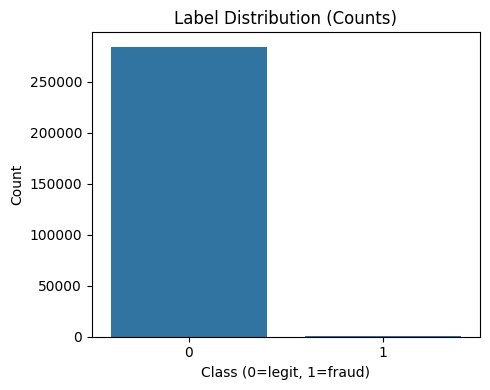

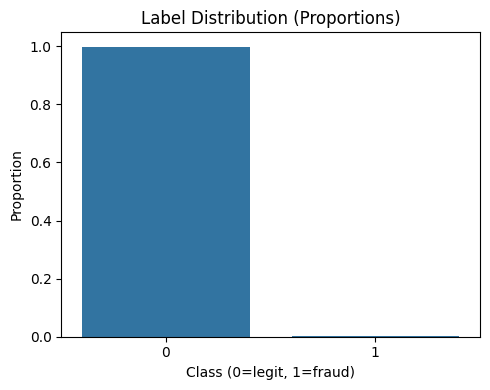

In [ ]:
#@title Label distribution
df["Class"] = df["Class"].astype(int)

label_counts = df["Class"].value_counts().sort_index()
label_props = df["Class"].value_counts(normalize=True).sort_index()

print("Label counts:\n", label_counts)
print("\nLabel proportions:\n", label_props)

os.makedirs("outputs/figures", exist_ok=True)

plt.figure(figsize=(5,4))
sns.barplot(x=label_counts.index.astype(str), y=label_counts.values)
plt.title("Label Distribution (Counts)")
plt.xlabel("Class (0=legit, 1=fraud)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/figures/label_distribution_counts.png", dpi=200)
plt.show()

plt.figure(figsize=(5,4))
sns.barplot(x=label_props.index.astype(str), y=label_props.values)
plt.title("Label Distribution (Proportions)")
plt.xlabel("Class (0=legit, 1=fraud)")
plt.ylabel("Proportion")
plt.tight_layout()
plt.savefig("outputs/figures/label_distribution_proportions.png", dpi=200)
plt.show()


## Exploratory Data Analysis (EDA)

Requested plots:
- Histograms / density
- Boxplots / violin
- Scatter / joint plots
- Pairwise relationships (sampled)
- Correlation matrix / heatmap
- PCA 2D/3D colored by class


Key features: ['Amount', 'Time']


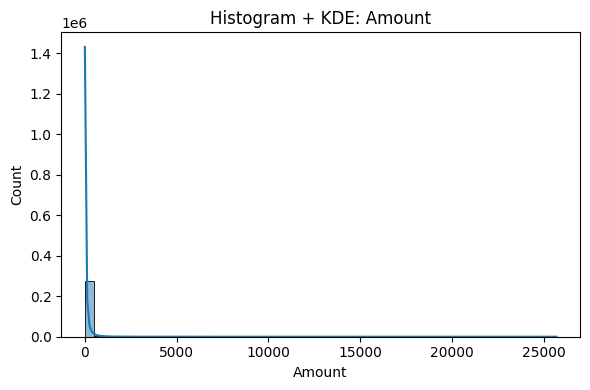

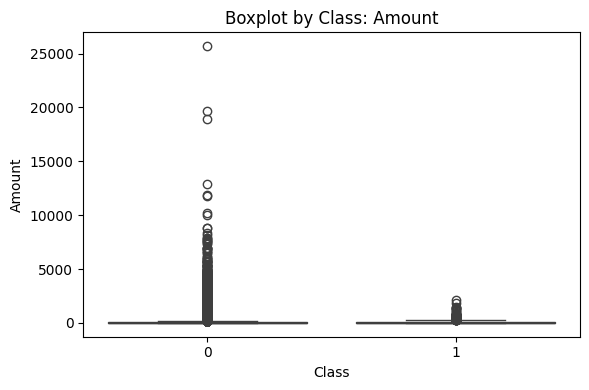

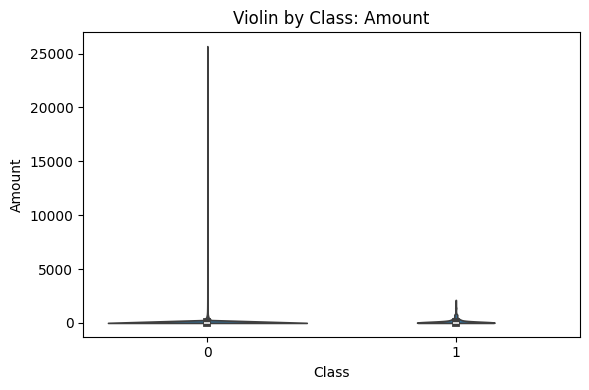

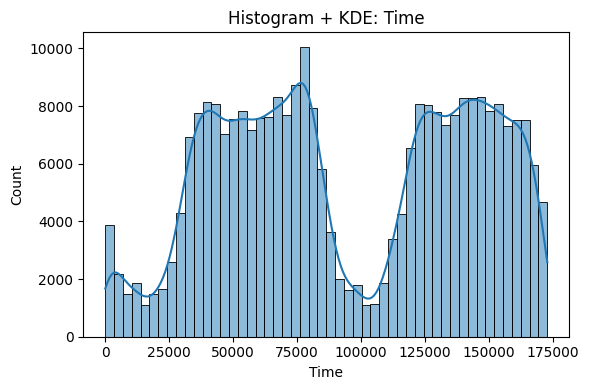

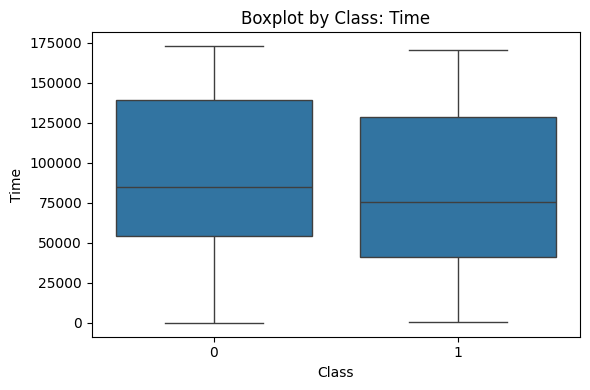

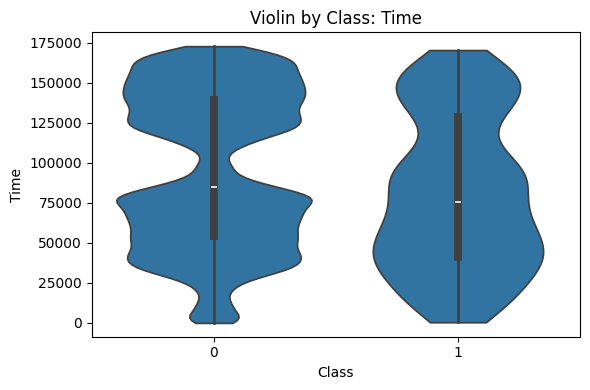

In [ ]:
#@title EDA: distributions for key features
key_features = [c for c in ["Amount", "Time"] if c in df.columns]
print("Key features:", key_features)

for col in key_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Histogram + KDE: {col}")
    plt.tight_layout()
    plt.savefig(f"outputs/figures/hist_kde_{col}.png", dpi=200)
    plt.show()

    plt.figure(figsize=(6,4))
    sns.boxplot(x=df["Class"].astype(str), y=df[col])
    plt.title(f"Boxplot by Class: {col}")
    plt.xlabel("Class")
    plt.tight_layout()
    plt.savefig(f"outputs/figures/boxplot_{col}_by_class.png", dpi=200)
    plt.show()

    plt.figure(figsize=(6,4))
    sns.violinplot(x=df["Class"].astype(str), y=df[col], cut=0)
    plt.title(f"Violin by Class: {col}")
    plt.xlabel("Class")
    plt.tight_layout()
    plt.savefig(f"outputs/figures/violin_{col}_by_class.png", dpi=200)
    plt.show()


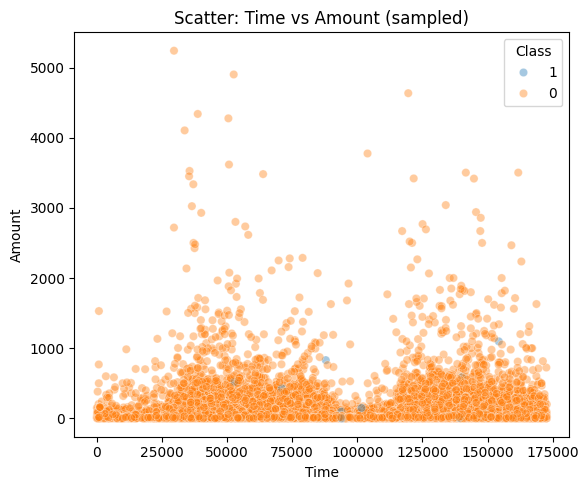

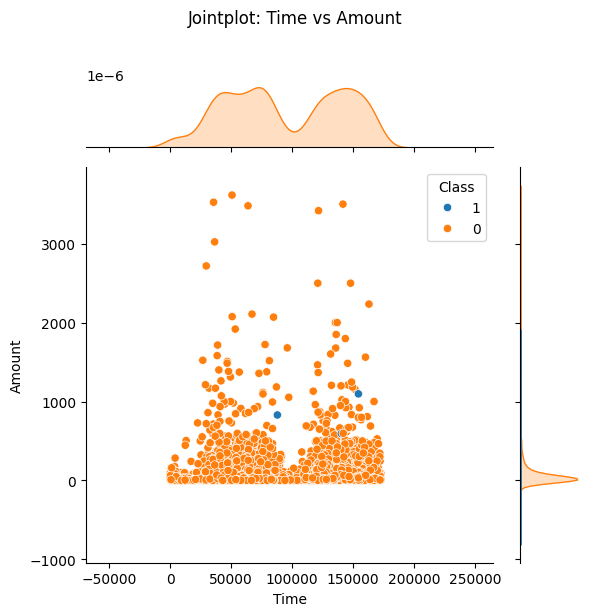

In [ ]:
#@title EDA: scatter (sampled) + jointplot
# Use sampling for performance
df_sample = df.sample(n=min(20000, len(df)), random_state=RANDOM_SEED)

if set(["Time", "Amount"]).issubset(df_sample.columns):
    plt.figure(figsize=(6,5))
    sns.scatterplot(data=df_sample, x="Time", y="Amount", hue=df_sample["Class"].astype(str), alpha=0.4)
    plt.title("Scatter: Time vs Amount (sampled)")
    plt.tight_layout()
    plt.savefig("outputs/figures/scatter_time_amount.png", dpi=200)
    plt.show()

    # Jointplot can be expensive; keep sample small
    df_joint = df.sample(n=min(5000, len(df)), random_state=RANDOM_SEED)
    g = sns.jointplot(data=df_joint, x="Time", y="Amount", hue=df_joint["Class"].astype(str), height=6)
    g.fig.suptitle("Jointplot: Time vs Amount", y=1.02)
    g.fig.tight_layout()
    g.fig.savefig("outputs/figures/jointplot_time_amount.png", dpi=200)
    plt.show()
else:
    print("Time/Amount not available; skipping scatter/jointplot")


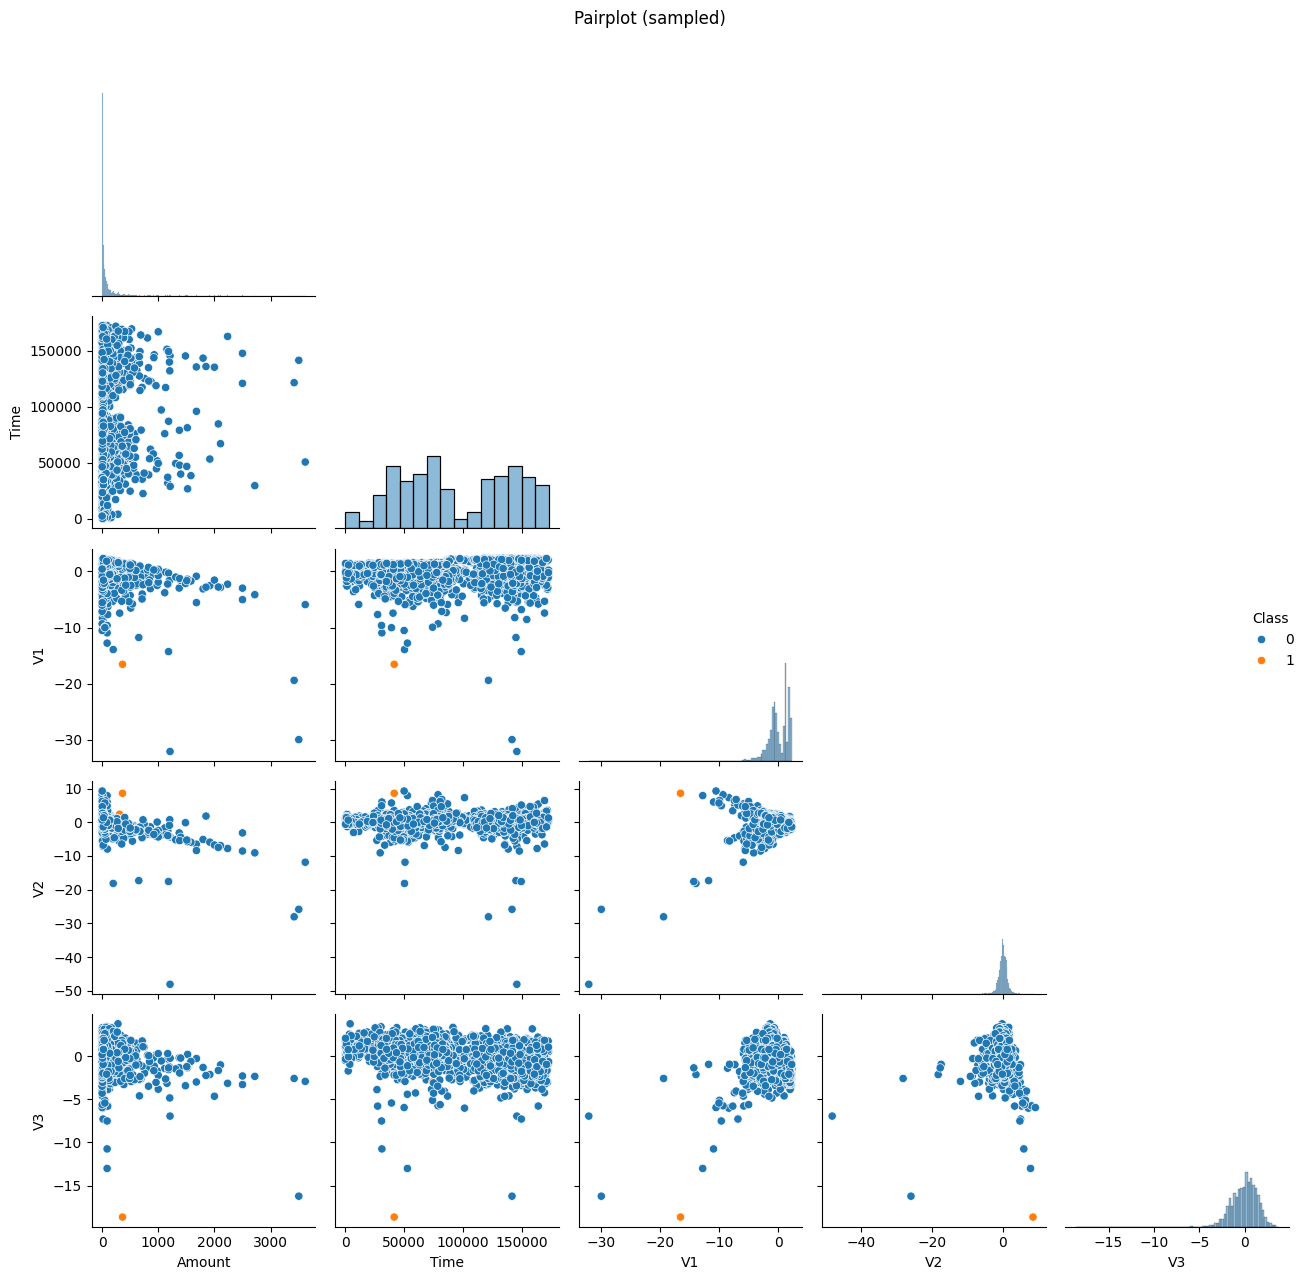

In [ ]:
#@title EDA: pairplot (sampled)
# Pairplot is heavy; sample further and limit columns
candidate_cols = [c for c in df.columns if c != "Class"]

# pick first few columns for display; for ULB dataset, V1..V28 exist
chosen = []
for name in ["Amount", "Time", "V1", "V2", "V3"]:
    if name in df.columns:
        chosen.append(name)

if len(chosen) >= 2:
    df_pair = df.sample(n=min(3000, len(df)), random_state=RANDOM_SEED)[chosen + ["Class"]]
    g = sns.pairplot(df_pair, hue="Class", corner=True, diag_kind="hist")
    g.fig.suptitle("Pairplot (sampled)", y=1.02)
    g.fig.tight_layout()
    g.fig.savefig("outputs/figures/pairplot_sampled.png", dpi=200)
    plt.show()
else:
    print("Not enough chosen features for pairplot")


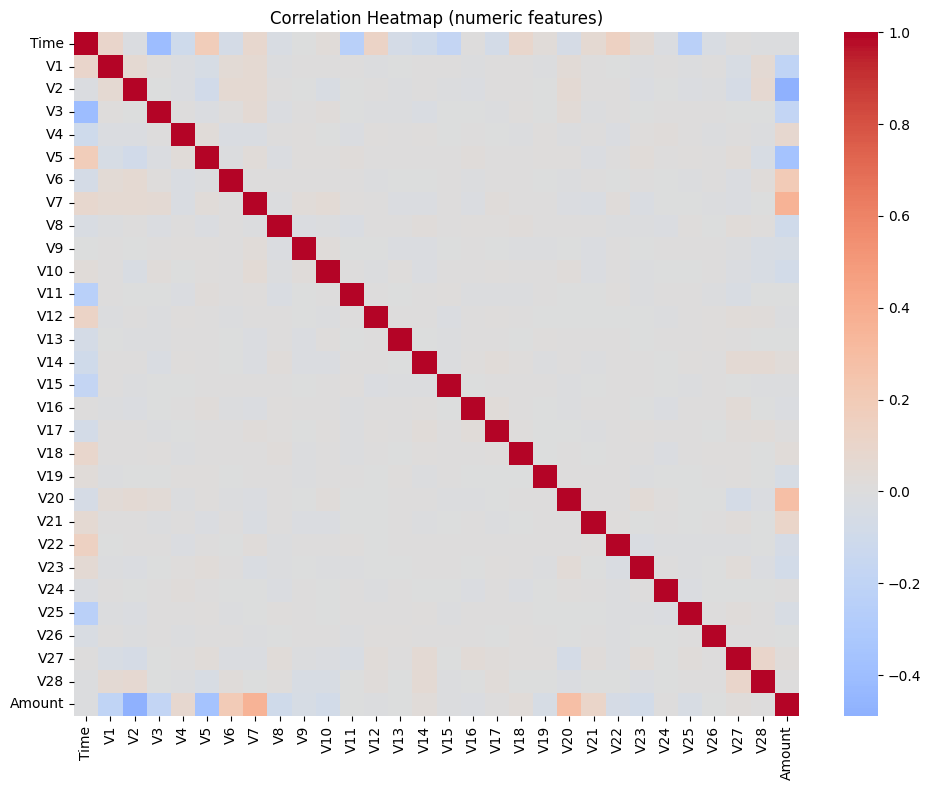

In [ ]:
#@title Correlation matrix + heatmap (sampled)
df_corr_sample = df.sample(n=min(20000, len(df)), random_state=RANDOM_SEED)

num_cols = [c for c in df_corr_sample.columns if c != "Class" and pd.api.types.is_numeric_dtype(df_corr_sample[c])]
corr = df_corr_sample[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (numeric features)")
plt.tight_layout()
plt.savefig("outputs/figures/correlation_heatmap.png", dpi=200)
plt.show()


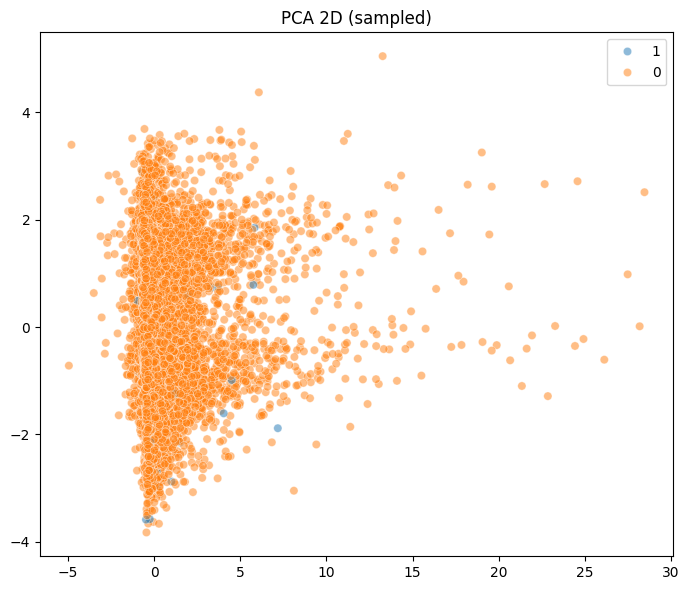

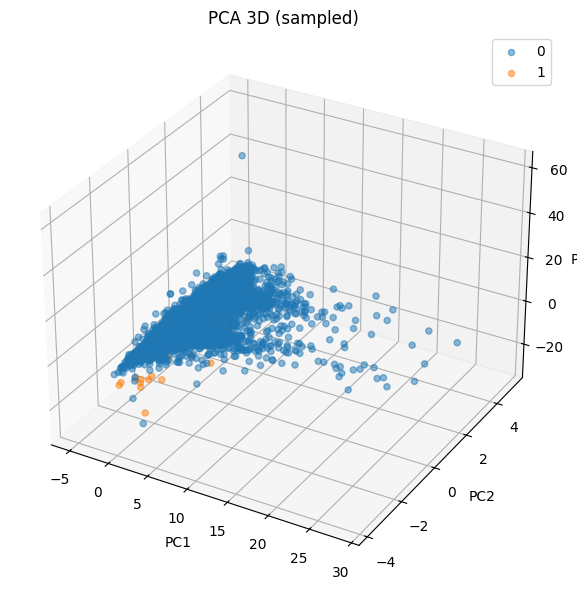

In [ ]:
#@title PCA visualization (2D/3D)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df_pca = df.sample(n=min(30000, len(df)), random_state=RANDOM_SEED)
X_pca = df_pca.drop(columns=["Class"])
y_pca = df_pca["Class"].values

# Basic scaling for PCA visualization
X_scaled = StandardScaler().fit_transform(X_pca)

pca2 = PCA(n_components=2, random_state=RANDOM_SEED)
Z2 = pca2.fit_transform(X_scaled)

plt.figure(figsize=(7,6))
sns.scatterplot(x=Z2[:,0], y=Z2[:,1], hue=y_pca.astype(str), alpha=0.5)
plt.title("PCA 2D (sampled)")
plt.tight_layout()
plt.savefig("outputs/figures/pca_2d.png", dpi=200)
plt.show()

pca3 = PCA(n_components=3, random_state=RANDOM_SEED)
Z3 = pca3.fit_transform(X_scaled)

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
for cls in np.unique(y_pca):
    idx = (y_pca == cls)
    ax.scatter(Z3[idx,0], Z3[idx,1], Z3[idx,2], label=str(cls), alpha=0.5)
ax.set_title("PCA 3D (sampled)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/figures/pca_3d.png", dpi=200)
plt.show()


## Outlier analysis

We provide an IQR-based outlier *detection* report and optional mitigation notes.

In fraud detection, outliers might be meaningful signals (e.g., unusually large transactions), so mitigation is optional.


In [ ]:
#@title Outlier detection via IQR (report)
def iqr_outlier_report(series: pd.Series, k: float = 1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - k * iqr
    hi = q3 + k * iqr
    outliers = (series < lo) | (series > hi)
    return {
        "q1": q1, "q3": q3, "iqr": iqr,
        "lower": lo, "upper": hi,
        "outlier_count": int(outliers.sum()),
        "outlier_rate": float(outliers.mean())
    }

for col in key_features:
    rep = iqr_outlier_report(df[col])
    print(col, rep)


Amount {'q1': np.float64(5.6), 'q3': np.float64(77.16499999999999), 'iqr': np.float64(71.565), 'lower': np.float64(-101.7475), 'upper': np.float64(184.5125), 'outlier_count': 31904, 'outlier_rate': 0.11201971861646659}
Time {'q1': np.float64(54201.5), 'q3': np.float64(139320.5), 'iqr': np.float64(85119.0), 'lower': np.float64(-73477.0), 'upper': np.float64(266999.0), 'outlier_count': 0, 'outlier_rate': 0.0}


## Train/test split

We split with stratification so the fraud ratio is preserved.


In [ ]:
#@title Split
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Class"])
y = df["Class"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train fraud rate:", y_train.mean(), "Test fraud rate:", y_test.mean())


Train shape: (227845, 30) Test shape: (56962, 30)
Train fraud rate: 0.001729245759178389 Test fraud rate: 0.0017204452090867595


## Preprocessing pipeline

General template handling both numeric and categorical columns:
- numeric: SimpleImputer(median) + RobustScaler
- categorical: SimpleImputer(most_frequent) + OneHotEncoder(handle_unknown='ignore')

For the ULB dataset, most columns are numeric.


In [ ]:
#@title Build preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

numeric_features = [c for c in X_train.columns if pd.api.types.is_numeric_dtype(X_train[c])]
categorical_features = [c for c in X_train.columns if not pd.api.types.is_numeric_dtype(X_train[c])]
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop",
    verbose_feature_names_out=True
)

preprocess


Numeric features: 30
Categorical features: 0


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## Imbalance handling (samplers and ensembles)

We define multiple strategies:
- None (baseline)
- SMOTE
- RandomUnderSampler
- SMOTEENN / SMOTETomek
- BalancedRandomForest / EasyEnsemble

These are used inside CV pipelines to avoid leakage.


In [ ]:
#@title Define imbalance strategies
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier

samplers = {
    "none": None,
    "smote": SMOTE(random_state=RANDOM_SEED),
    "under": RandomUnderSampler(random_state=RANDOM_SEED),
    "smoteenn": SMOTEENN(random_state=RANDOM_SEED),
    "smotetomek": SMOTETomek(random_state=RANDOM_SEED),
}

samplers


{'none': None,
 'smote': SMOTE(random_state=42),
 'under': RandomUnderSampler(random_state=42),
 'smoteenn': SMOTEENN(random_state=42),
 'smotetomek': SMOTETomek(random_state=42)}

## Modeling: classical ML

We train and compare:
- LogisticRegression
- RandomForestClassifier
- LinearSVC (and optional SVC)
- XGBoost
- LightGBM

We use StratifiedKFold and leakage-safe pipelines.


In [ ]:
#@title Define ML models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC, SVC
import xgboost as xgb
import lightgbm as lgb

models = {
    "logreg": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED)
}




# models = {
#     "logreg": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED),
#     "rf": RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1, class_weight="balanced_subsample"),
#     "linearsvc": LinearSVC(random_state=RANDOM_SEED, class_weight="balanced"),
#     # kernel SVC is expensive; enable if needed
#     "svc_rbf": SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_SEED),
#     "xgb": xgb.XGBClassifier(
#         n_estimators=500,
#         learning_rate=0.05,
#         max_depth=4,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         reg_lambda=1.0,
#         random_state=RANDOM_SEED,
#         tree_method="hist",
#         eval_metric="auc",
#     ),
#     "lgbm": lgb.LGBMClassifier(
#         n_estimators=800,
#         learning_rate=0.03,
#         num_leaves=31,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         random_state=RANDOM_SEED,
#     )
# }

models


{'logreg': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)}

#Break for finding the error

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support
from sklearn.base import clone
from sklearn.utils.class_weight import compute_class_weight
from imblearn.pipeline import Pipeline as ImbPipeline

In [ ]:
# Reduced n_splits for faster execution. Set to 5 for more robust evaluation.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

In [ ]:
# Helper to get predicted probabilities/scores
def get_scores(estimator, X, y=None):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X)
    # fallback
    return estimator.predict(X)

In [ ]:
results = []

In [ ]:
for model_name, model in models.items():
    for sampler_name, sampler in samplers.items():
        # Skip sampler combos that are not meaningful for some models if desired
        # We'll keep general.
        pipe_steps = [("preprocess", preprocess)]
        if sampler is not None:
            pipe_steps.append(("sampler", sampler))
        pipe_steps.append(("model", clone(model)))

        pipe = ImbPipeline(steps=pipe_steps)

        fold_roc = []
        fold_ap = []
        fold_prec = []
        fold_rec = []
        fold_f1 = []
        t0 = time.time()

        for train_idx, val_idx in cv.split(X_train, y_train):
            X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

            pipe.fit(X_tr, y_tr)
            y_score = get_scores(pipe, X_va)
            y_pred = (y_score >= 0.5).astype(int)

            fold_roc.append(roc_auc_score(y_va, y_score))
            fold_ap.append(average_precision_score(y_va, y_score))
            p, r, f, _ = precision_recall_fscore_support(y_va, y_pred, average="binary", zero_division=0)
            fold_prec.append(p)
            fold_rec.append(r)
            fold_f1.append(f)

        train_time = time.time() - t0

        results.append({
            "model": model_name,
            "sampler": sampler_name,
            "roc_auc_mean": float(np.mean(fold_roc)),
            "roc_auc_std": float(np.std(fold_roc)),
            "ap_mean": float(np.mean(fold_ap)),
            "ap_std": float(np.std(fold_ap)),
            "precision_mean@0.5": float(np.mean(fold_prec)),
            "recall_mean@0.5": float(np.mean(fold_rec)),
            "f1_mean@0.5": float(np.mean(fold_f1)),
            "train_time_sec": float(train_time),
        })

In [ ]:
results_df = pd.DataFrame(results).sort_values(by=["ap_mean", "roc_auc_mean"], ascending=False)
results_df.head(20)

,model,sampler,roc_auc_mean,roc_auc_std,ap_mean,ap_std,precision_mean@0.5,recall_mean@0.5,f1_mean@0.5,train_time_sec
0,logreg,none,0.976500,0.006879,0.741256,0.024547,0.060707,0.908609,0.113788,15.813473
3,logreg,smoteenn,0.975003,0.008246,0.739966,0.023573,0.056228,0.911154,0.105914,1967.640984
1,logreg,smote,0.975598,0.008249,0.738654,0.018334,0.057769,0.908609,0.108625,21.106063
4,logreg,smotetomek,0.975598,0.008249,0.738654,0.018334,0.057769,0.908609,0.108625,1914.060228
2,logreg,under,0.975319,0.012256,0.542801,0.059707,0.037296,0.923838,0.071686,3.281788


In [ ]:
#@title Save model comparison table
os.makedirs("outputs", exist_ok=True)
results_df.to_csv("outputs/model_comparison.csv", index=False)
print("Saved: outputs/model_comparison.csv")


Saved: outputs/model_comparison.csv


## Pick best model and evaluate on holdout test

We select the best pipeline by AP (PR-AUC) and evaluate on test.


Best pipeline: logreg + none
Fit time (sec): 6.519744873046875
ROC AUC: 0.9721215424126882
Average Precision (AP): 0.715554837539796

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

Confusion matrix:
 [[55482  1382]
 [    8    90]]


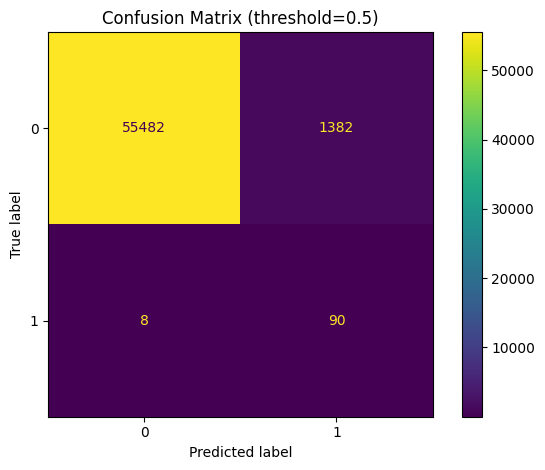

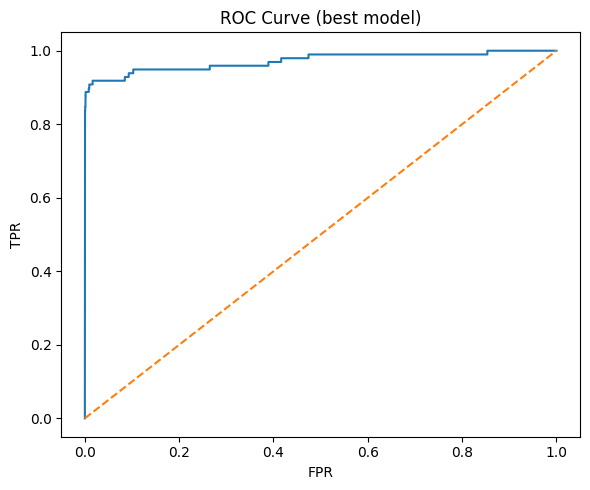

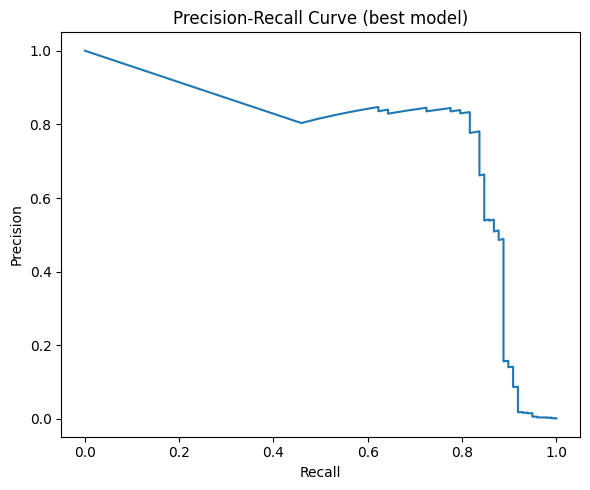

In [ ]:
#@title Fit best model and evaluate on test
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve,
    RocCurveDisplay, PrecisionRecallDisplay
)

best_row = results_df.iloc[0]
best_model_name = best_row["model"]
best_sampler_name = best_row["sampler"]

best_model = clone(models[best_model_name])
best_sampler = samplers[best_sampler_name]

pipe_steps = [("preprocess", preprocess)]
if best_sampler is not None:
    pipe_steps.append(("sampler", best_sampler))
pipe_steps.append(("model", best_model))

from imblearn.pipeline import Pipeline as ImbPipeline
best_pipe = ImbPipeline(steps=pipe_steps)

t0 = time.time()
best_pipe.fit(X_train, y_train)
fit_time = time.time() - t0

y_test_score = get_scores(best_pipe, X_test)
y_test_pred = (y_test_score >= 0.5).astype(int)

print("Best pipeline:", best_model_name, "+", best_sampler_name)
print("Fit time (sec):", fit_time)
print("ROC AUC:", roc_auc_score(y_test, y_test_score))
print("Average Precision (AP):", average_precision_score(y_test, y_test_score))
print("\nClassification report:\n", classification_report(y_test, y_test_pred, zero_division=0))

cm = confusion_matrix(y_test, y_test_pred)
print("Confusion matrix:\n", cm)

from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
disp.ax_.set_title("Confusion Matrix (threshold=0.5)")
plt.tight_layout()
plt.savefig("outputs/figures/confusion_matrix_best.png", dpi=200)
plt.show()

# ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_test_score)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle='--')
plt.title("ROC Curve (best model)")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.tight_layout()
plt.savefig("outputs/figures/roc_curve_best.png", dpi=200)
plt.show()

# PR curve
prec, rec, pr_thresholds = precision_recall_curve(y_test, y_test_score)
plt.figure(figsize=(6,5))
plt.plot(rec, prec)
plt.title("Precision-Recall Curve (best model)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.tight_layout()
plt.savefig("outputs/figures/pr_curve_best.png", dpi=200)
plt.show()


## Calibration plots and Brier score

Calibration curve (reliability diagram) helps assess probability quality.


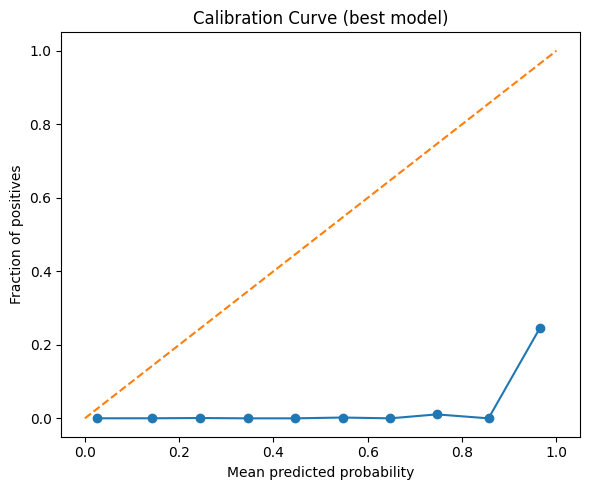

Brier score loss: 0.023505835144642648


In [ ]:
#@title Calibration curve + Brier score
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

prob_true, prob_pred = calibration_curve(y_test, y_test_score, n_bins=10, strategy="uniform")

plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1], linestyle='--')
plt.title("Calibration Curve (best model)")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.tight_layout()
plt.savefig("outputs/figures/calibration_curve_best.png", dpi=200)
plt.show()

brier = brier_score_loss(y_test, y_test_score)
print("Brier score loss:", brier)


## Threshold analysis

We evaluate multiple thresholds and plot precision/recall/F1.


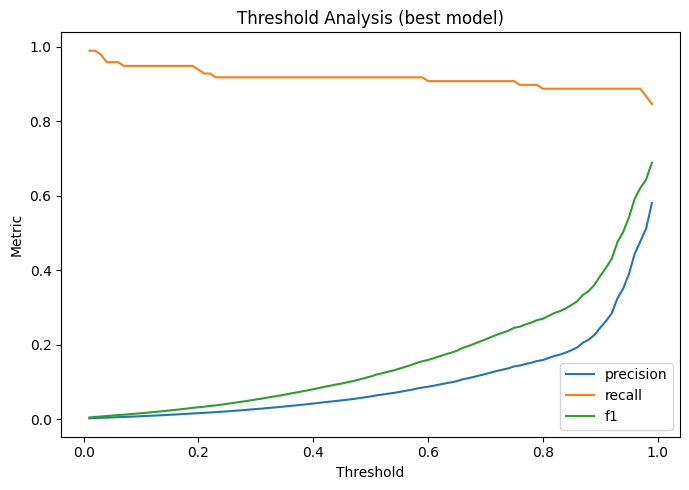

Saved: outputs/threshold_metrics.csv


,threshold,precision,recall,f1
98,0.99,0.580420,0.846939,0.688797
97,0.98,0.512048,0.867347,0.643939
96,0.97,0.478022,0.887755,0.621429
95,0.96,0.443878,0.887755,0.591837
94,0.95,0.390135,0.887755,0.542056
93,0.94,0.350806,0.887755,0.502890
92,0.93,0.324627,0.887755,0.475410
91,0.92,0.284314,0.887755,0.430693
90,0.91,0.263636,0.887755,0.406542
89,0.90,0.245763,0.887755,0.384956


In [ ]:
#@title Threshold analysis
thresholds = np.linspace(0.01, 0.99, 99)
rows = []

for thr in thresholds:
    y_pred_thr = (y_test_score >= thr).astype(int)
    p, r, f, _ = precision_recall_fscore_support(y_test, y_pred_thr, average="binary", zero_division=0)
    rows.append({"threshold": thr, "precision": p, "recall": r, "f1": f})

thr_df = pd.DataFrame(rows)

plt.figure(figsize=(7,5))
plt.plot(thr_df["threshold"], thr_df["precision"], label="precision")
plt.plot(thr_df["threshold"], thr_df["recall"], label="recall")
plt.plot(thr_df["threshold"], thr_df["f1"], label="f1")
plt.title("Threshold Analysis (best model)")
plt.xlabel("Threshold")
plt.ylabel("Metric")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/figures/threshold_analysis_best.png", dpi=200)
plt.show()

thr_df.to_csv("outputs/threshold_metrics.csv", index=False)
print("Saved: outputs/threshold_metrics.csv")
thr_df.sort_values("f1", ascending=False).head(10)


## Feature importance

We provide:
- Permutation importance
- Model-based importances when available
- SHAP global importance


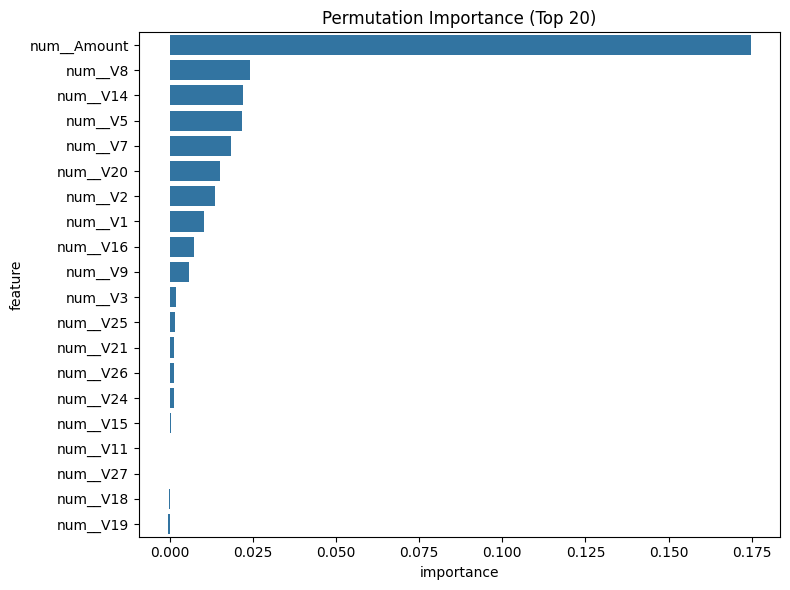

Saved: outputs/permutation_importance.csv


In [ ]:
#@title Permutation importance (best model)
from sklearn.inspection import permutation_importance

# For performance, sample test set
sample_n = min(20000, len(X_test))
X_test_s = X_test.sample(n=sample_n, random_state=RANDOM_SEED)
y_test_s = y_test.loc[X_test_s.index]

# Need numpy arrays after preprocessing; use pipeline to predict
perm = permutation_importance(best_pipe, X_test_s, y_test_s, n_repeats=3, random_state=RANDOM_SEED, n_jobs=-1, scoring="average_precision")

# Feature names
try:
    feat_names = best_pipe.named_steps["preprocess"].get_feature_names_out()
except Exception:
    feat_names = np.array([f"f{i}" for i in range(len(perm.importances_mean))])

imp_df = pd.DataFrame({"feature": feat_names, "importance": perm.importances_mean}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=imp_df.head(20), x="importance", y="feature")
plt.title("Permutation Importance (Top 20)")
plt.tight_layout()
plt.savefig("outputs/figures/permutation_importance_top20.png", dpi=200)
plt.show()

imp_df.to_csv("outputs/permutation_importance.csv", index=False)
print("Saved: outputs/permutation_importance.csv")


## Explainability: SHAP

TreeExplainer for tree-based models. For non-tree models, KernelExplainer can be used, but is more expensive.


In [ ]:
#@title SHAP explainability (best model)
import shap

# Build background and foreground samples
bg_n = 2000
fg_n = 2000

bg = X_train.sample(n=min(bg_n, len(X_train)), random_state=RANDOM_SEED)
fg = X_test.sample(n=min(fg_n, len(X_test)), random_state=RANDOM_SEED)

model_step = best_pipe.named_steps["model"]
pre_step = best_pipe.named_steps["preprocess"]

bg_t = pre_step.transform(bg)
fg_t = pre_step.transform(fg)

try:
    feat_names = pre_step.get_feature_names_out()
except Exception:
    feat_names = None

# TreeExplainer works for many tree-based models
is_tree = any(k in best_model_name for k in ["rf", "xgb", "lgbm"]) or hasattr(model_step, "feature_importances_")

if is_tree:
    explainer = shap.TreeExplainer(model_step)
    shap_values = explainer.shap_values(fg_t)

    # Global importance bar plot
    plt.figure(figsize=(8,6))
    shap.summary_plot(shap_values, fg_t, feature_names=feat_names, plot_type="bar", show=False, max_display=20)
    plt.tight_layout()
    plt.savefig("outputs/figures/shap_summary_bar.png", dpi=200)
    plt.show()

    # Beeswarm
    plt.figure(figsize=(8,6))
    shap.summary_plot(shap_values, fg_t, feature_names=feat_names, show=False, max_display=20)
    plt.tight_layout()
    plt.savefig("outputs/figures/shap_summary_beeswarm.png", dpi=200)
    plt.show()

else:
    print("Best model is not tree-like; consider KernelExplainer (slow). Skipping SHAP.")


Best model is not tree-like; consider KernelExplainer (slow). Skipping SHAP.


## Explainability: LIME (local explanations)

We generate a LIME explanation for one test sample.


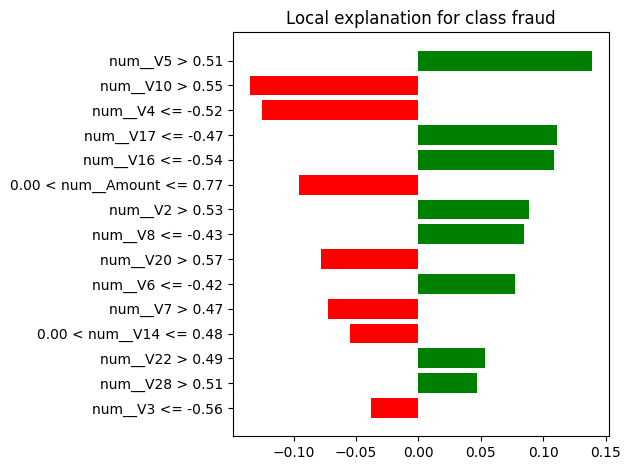

In [ ]:
#@title LIME local explanation
import lime
import lime.lime_tabular

# Use smaller transformed representation for LIME
X_train_t = preprocess.fit_transform(X_train)
X_test_t = preprocess.transform(X_test)

try:
    feat_names = preprocess.get_feature_names_out()
except Exception:
    feat_names = [f"f{i}" for i in range(X_train_t.shape[1])]

# Fit a model on transformed data for LIME wrapper
lime_model = clone(models[best_model_name])
lime_model.fit(X_train_t, y_train)

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_t),
    feature_names=list(feat_names),
    class_names=["legit", "fraud"],
    mode="classification"
)

i = 0
exp = explainer.explain_instance(
    data_row=np.array(X_test_t[i]),
    predict_fn=lime_model.predict_proba,
    num_features=15
)

fig = exp.as_pyplot_figure()
fig.tight_layout()
fig.savefig("outputs/figures/lime_local_explanation.png", dpi=200)
plt.show()


## Deep learning: MLP

We train an MLP with class weights and plot training curves.


In [ ]:
#@title TensorFlow / Keras setup
!pip -q install -U "tensorflow>=2.15"
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 18.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.34.1 which is incompatible.
google-cloud-dataplex 2.16.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.34.1 which is incompatible.
google-cloud-bigquery-storage 2.36.2 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.34.1 which is incompatible.
proto-plus 1.27.1 requires protobuf<7.0.0,>=3.19.0, but you ha

In [ ]:
#@title Prepare data for deep learning
X_train_t = preprocess.fit_transform(X_train)
X_test_t = preprocess.transform(X_test)

X_train_t = np.asarray(X_train_t).astype(np.float32)
X_test_t = np.asarray(X_test_t).astype(np.float32)

y_train_np = y_train.values.astype(np.int32)
y_test_np = y_test.values.astype(np.int32)

# Validation split from training
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_t, y_train_np, test_size=0.2, random_state=RANDOM_SEED, stratify=y_train_np
)

# Class weights
classes = np.array([0,1])
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_tr)
class_weight = {0: cw[0], 1: cw[1]}
print("Class weights:", class_weight)


Class weights: {0: np.float64(0.5008655700946906), 1: np.float64(289.32698412698414)}


In [ ]:
#@title Train MLP
def build_mlp(input_dim, hidden_units=[128, 64], dropout=0.3, lr=1e-3):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for u in hidden_units:
        model.add(layers.Dense(u, activation="relu"))
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation="sigmoid"))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc"), keras.metrics.Precision(name="precision"), keras.metrics.Recall(name="recall")]
    )
    return model

mlp = build_mlp(X_tr.shape[1])

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", patience=3, factor=0.5)
]

history = mlp.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=2048,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.9269 - auc: 0.9176 - loss: 0.4060 - precision: 0.0197 - recall: 0.8476 - val_accuracy: 0.9709 - val_auc: 0.9390 - val_loss: 0.2472 - val_precision: 0.0491 - val_recall: 0.8608 - learning_rate: 0.0010
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.9659 - auc: 0.9708 - loss: 0.2008 - precision: 0.0443 - recall: 0.9111 - val_accuracy: 0.9754 - val_auc: 0.9437 - val_loss: 0.1396 - val_precision: 0.0578 - val_recall: 0.8608 - learning_rate: 0.0010
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9655 - auc: 0.9807 - loss: 0.1649 - precision: 0.0440 - recall: 0.9143 - val_accuracy: 0.9735 - val_auc: 0.9487 - val_loss: 0.1162 - val_precision: 0.0538 - val_recall: 0.8608 - learning_rate: 0.0010
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9680 - auc: 0.9836 - loss: 0.1521 - precision: 0.0475 - recall: 0.9206 - val_accuracy: 0.9713 - val_auc: 0.9503 - val_loss: 0.1119 - val_pre

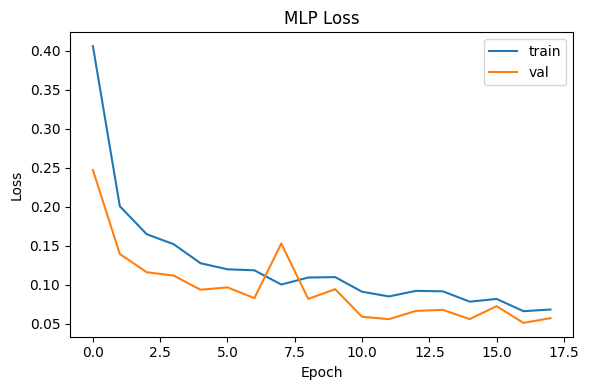

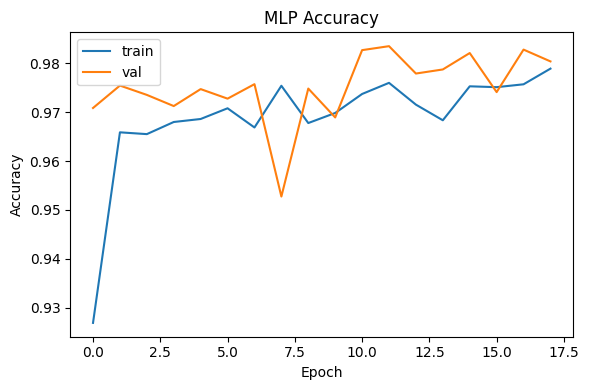

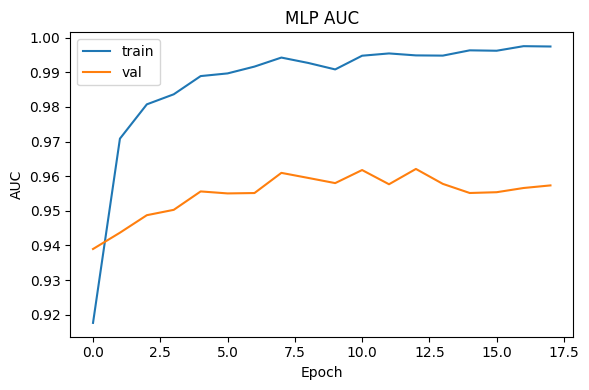

In [ ]:
#@title Plot training curves (loss/accuracy/AUC)
hist = pd.DataFrame(history.history)

plt.figure(figsize=(6,4))
plt.plot(hist["loss"], label="train")
plt.plot(hist["val_loss"], label="val")
plt.title("MLP Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/figures/mlp_loss.png", dpi=200)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(hist["accuracy"], label="train")
plt.plot(hist["val_accuracy"], label="val")
plt.title("MLP Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/figures/mlp_accuracy.png", dpi=200)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(hist["auc"], label="train")
plt.plot(hist["val_auc"], label="val")
plt.title("MLP AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/figures/mlp_auc.png", dpi=200)
plt.show()


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
MLP ROC AUC: 0.9776850315252719
MLP AP: 0.7071849415988098
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.90      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.98      0.99     56962



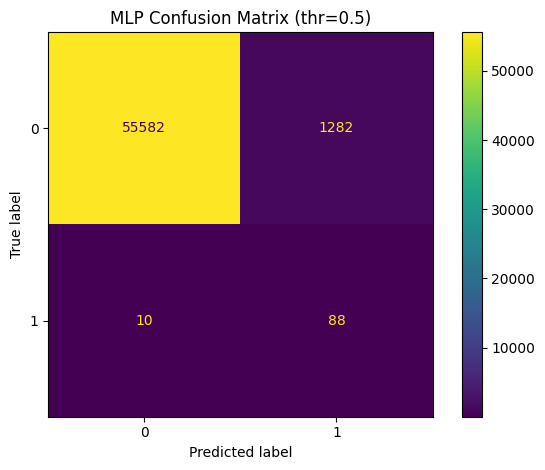

In [ ]:
#@title Evaluate MLP on test
y_mlp_score = mlp.predict(X_test_t, batch_size=4096).ravel()
y_mlp_pred = (y_mlp_score >= 0.5).astype(int)

print("MLP ROC AUC:", roc_auc_score(y_test_np, y_mlp_score))
print("MLP AP:", average_precision_score(y_test_np, y_mlp_score))
print(classification_report(y_test_np, y_mlp_pred, zero_division=0))

disp = ConfusionMatrixDisplay.from_predictions(y_test_np, y_mlp_pred)
disp.ax_.set_title("MLP Confusion Matrix (thr=0.5)")
plt.tight_layout()
plt.savefig("outputs/figures/confusion_matrix_mlp.png", dpi=200)
plt.show()


## Optional: Autoencoder anomaly detector

Train an autoencoder mostly on non-fraud; use reconstruction error to flag anomalies.
This is optional and illustrative.


Epoch 1/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.9328 - val_loss: 0.4026
Epoch 2/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.2469 - val_loss: 0.1937
Epoch 3/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1278 - val_loss: 0.1220
Epoch 4/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0820 - val_loss: 0.0918
Epoch 5/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0558 - val_loss: 0.0712
Epoch 6/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0427 - val_loss: 0.0659
Epoch 7/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0367 - val_loss: 0.0554
Epoch 8/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0323 - val_loss: 0.0520
Epoch 9/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0297 - val_loss: 0.0486
Epoch 10/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0271 - val_loss: 0.0463
Epoch 11/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0258 - val_loss: 0.0439
Epoch 12/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0

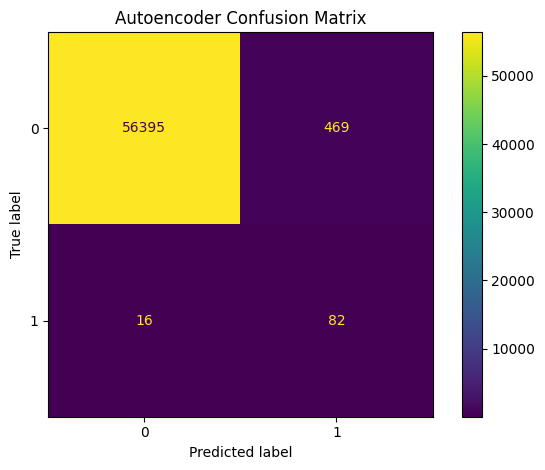

In [ ]:
#@title Autoencoder (optional)
use_autoencoder = True
if not use_autoencoder:
    print("Skipping autoencoder")
else:
    # Train on majority class only
    X_major = X_tr[y_tr == 0]

    input_dim = X_major.shape[1]
    inp = keras.Input(shape=(input_dim,))
    x = layers.Dense(128, activation="relu")(inp)
    x = layers.Dense(64, activation="relu")(x)
    z = layers.Dense(32, activation="relu")(x)
    x = layers.Dense(64, activation="relu")(z)
    x = layers.Dense(128, activation="relu")(x)
    out = layers.Dense(input_dim, activation="linear")(x)

    ae = keras.Model(inp, out)
    ae.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")

    h = ae.fit(
        X_major, X_major,
        validation_data=(X_val, X_val),
        epochs=20,
        batch_size=2048,
        verbose=1
    )

    # Reconstruction error threshold based on validation
    val_recon = ae.predict(X_val, batch_size=4096)
    val_err = np.mean((X_val - val_recon) ** 2, axis=1)
    thr = np.quantile(val_err, 0.99)
    print("Reconstruction error threshold (99th percentile):", thr)

    test_recon = ae.predict(X_test_t, batch_size=4096)
    test_err = np.mean((X_test_t - test_recon) ** 2, axis=1)
    y_ae_pred = (test_err >= thr).astype(int)

    print("Autoencoder classification report (thresholded):")
    print(classification_report(y_test_np, y_ae_pred, zero_division=0))

    disp = ConfusionMatrixDisplay.from_predictions(y_test_np, y_ae_pred)
    disp.ax_.set_title("Autoencoder Confusion Matrix")
    plt.tight_layout()
    plt.savefig("outputs/figures/confusion_matrix_autoencoder.png", dpi=200)
    plt.show()


## Hyperparameter tuning examples

We include templates for GridSearchCV / RandomizedSearchCV and Optuna.
Use smaller search spaces in Colab to avoid long runtimes.


In [ ]:
#@title GridSearchCV example (Logistic Regression)
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline

pipe = ImbPipeline([
    ("preprocess", preprocess),
    ("sampler", SMOTE(random_state=RANDOM_SEED)),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_SEED))
])

param_grid = {
    "model__C": [0.1, 1.0, 10.0],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"],
}

gs = GridSearchCV(pipe, param_grid=param_grid, scoring="average_precision", cv=3, n_jobs=-1)
gs.fit(X_train, y_train)
print("Best params:", gs.best_params_)
print("Best AP:", gs.best_score_)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best params: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best AP: 0.7535112314072476


In [ ]:
#@title Optuna example (LightGBM)
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 128),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "random_state": RANDOM_SEED,
    }

    model = lgb.LGBMClassifier(**params)
    pipe = ImbPipeline([
        ("preprocess", preprocess),
        ("sampler", SMOTE(random_state=RANDOM_SEED)),
        ("model", model)
    ])

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
    scores = []
    for tr_idx, va_idx in cv.split(X_train, y_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        pipe.fit(X_tr, y_tr)
        y_score = get_scores(pipe, X_va)
        scores.append(average_precision_score(y_va, y_score))
    return float(np.mean(scores))

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)
print("Best AP:", study.best_value)
print("Best params:", study.best_params)


[I 2026-04-01 07:11:26,616] A new study created in memory with name: no-name-c8ee065a-a517-477a-8f16-fcc43c0ed31f


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.094655 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.086720 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.091560 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-01 07:13:42,901] Trial 0 finished with value: 0.8486485209043538 and parameters: {'n_estimators': 781, 'learning_rate': 0.10764886131489251, 'num_leaves': 112, 'subsample': 0.6415096322072344, 'colsample_bytree': 0.5526188796418652}. Best is trial 0 with value: 0.8486485209043538.


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.177663 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.110373 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.099555 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-01 07:14:56,551] Trial 1 finished with value: 0.8121082139357991 and parameters: {'n_estimators': 241, 'learning_rate': 0.141483133923913, 'num_leaves': 83, 'subsample': 0.8265493718136001, 'colsample_bytree': 0.8694346151218539}. Best is trial 0 with value: 0.8486485209043538.


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.102254 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.099387 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.102637 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-01 07:17:43,396] Trial 2 finished with value: 0.6031864964982664 and parameters: {'n_estimators': 967, 'learning_rate': 0.1786274685906144, 'num_leaves': 19, 'subsample': 0.735049990056097, 'colsample_bytree': 0.7719930827020125}. Best is trial 0 with value: 0.8486485209043538.


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.101637 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.107987 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.102981 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-01 07:19:05,377] Trial 3 finished with value: 0.749398022780062 and parameters: {'n_estimators': 263, 'learning_rate': 0.011841796346351128, 'num_leaves': 101, 'subsample': 0.8628028631003614, 'colsample_bytree': 0.9273877999789332}. Best is trial 0 with value: 0.8486485209043538.


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.178806 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.098420 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.109886 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-01 07:20:39,685] Trial 4 finished with value: 0.7431426737775233 and parameters: {'n_estimators': 389, 'learning_rate': 0.002516665770416104, 'num_leaves': 84, 'subsample': 0.9220210718888995, 'colsample_bytree': 0.7252656659988512}. Best is trial 0 with value: 0.8486485209043538.


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.098916 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.103008 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.105059 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-01 07:22:00,417] Trial 5 finished with value: 0.7537117694707948 and parameters: {'n_estimators': 351, 'learning_rate': 0.009578272014735241, 'num_leaves': 88, 'subsample': 0.7816226764828139, 'colsample_bytree': 0.6437850651436853}. Best is trial 0 with value: 0.8486485209043538.


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.104545 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.112343 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.190234 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-01 07:24:24,182] Trial 6 finished with value: 0.8302891306522172 and parameters: {'n_estimators': 562, 'learning_rate': 0.11683196742053042, 'num_leaves': 34, 'subsample': 0.9291990946569342, 'colsample_bytree': 0.8064530505038217}. Best is trial 0 with value: 0.8486485209043538.


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.102701 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.100969 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.102303 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-01 07:25:13,135] Trial 7 finished with value: 0.7356208139810881 and parameters: {'n_estimators': 205, 'learning_rate': 0.0025687349039301703, 'num_leaves': 41, 'subsample': 0.6074077682480523, 'colsample_bytree': 0.8165078480852872}. Best is trial 0 with value: 0.8486485209043538.


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018161 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.160112 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.154403 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-01 07:26:33,405] Trial 8 finished with value: 0.7414741951990574 and parameters: {'n_estimators': 363, 'learning_rate': 0.0015219274672643019, 'num_leaves': 101, 'subsample': 0.9158631427823039, 'colsample_bytree': 0.5407590817115759}. Best is trial 0 with value: 0.8486485209043538.


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.175284 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.183814 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.178177 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-01 07:28:37,123] Trial 9 finished with value: 0.8472287436963275 and parameters: {'n_estimators': 416, 'learning_rate': 0.03841927745117508, 'num_leaves': 49, 'subsample': 0.6920538704610544, 'colsample_bytree': 0.9863661001963075}. Best is trial 0 with value: 0.8486485209043538.


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.157081 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.085926 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.089533 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-01 07:31:49,343] Trial 10 finished with value: 0.8547158064041082 and parameters: {'n_estimators': 918, 'learning_rate': 0.04140069673129052, 'num_leaves': 128, 'subsample': 0.518838387827768, 'colsample_bytree': 0.5013397530032103}. Best is trial 10 with value: 0.8547158064041082.


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.089667 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.090159 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.086899 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-01 07:35:02,292] Trial 11 finished with value: 0.8541504613022916 and parameters: {'n_estimators': 903, 'learning_rate': 0.03805973474877775, 'num_leaves': 122, 'subsample': 0.5246247897795207, 'colsample_bytree': 0.5048862096318311}. Best is trial 10 with value: 0.8547158064041082.


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.100817 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.110551 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.100829 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-01 07:39:26,816] Trial 12 finished with value: 0.8534381543456684 and parameters: {'n_estimators': 1193, 'learning_rate': 0.036663932678867306, 'num_leaves': 123, 'subsample': 0.5039379913323877, 'colsample_bytree': 0.6199269728010063}. Best is trial 10 with value: 0.8547158064041082.


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.092028 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.106133 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.113366 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-01 07:42:47,497] Trial 13 finished with value: 0.8530238333251167 and parameters: {'n_estimators': 877, 'learning_rate': 0.03490274546083565, 'num_leaves': 127, 'subsample': 0.5082942010113412, 'colsample_bytree': 0.518923979436915}. Best is trial 10 with value: 0.8547158064041082.


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.098389 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.100011 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 151634, number of negative: 151634
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.115251 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 303268, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-01 07:47:02,468] Trial 14 finished with value: 0.8520159990978402 and parameters: {'n_estimators': 1080, 'learning_rate': 0.021305751448764964, 'num_leaves': 61, 'subsample': 0.5851616825430668, 'colsample_bytree': 0.6226281360906951}. Best is trial 10 with value: 0.8547158064041082.


Best AP: 0.8547158064041082
Best params: {'n_estimators': 918, 'learning_rate': 0.04140069673129052, 'num_leaves': 128, 'subsample': 0.518838387827768, 'colsample_bytree': 0.5013397530032103}


## Save and load models

- Save best sklearn-style pipeline with joblib
- Save Keras MLP model in .keras format


In [ ]:
#@title Save models
import joblib

os.makedirs("outputs/models", exist_ok=True)

# Save best pipeline
joblib.dump(best_pipe, "outputs/models/best_pipeline.joblib")
print("Saved: outputs/models/best_pipeline.joblib")

# Save MLP
mlp.save("outputs/models/mlp_model.keras")
print("Saved: outputs/models/mlp_model.keras")


Saved: outputs/models/best_pipeline.joblib
Saved: outputs/models/mlp_model.keras


In [ ]:
#@title Load models
import joblib
from tensorflow import keras

loaded_pipe = joblib.load("outputs/models/best_pipeline.joblib")
print("Loaded pipeline:", type(loaded_pipe))

loaded_mlp = keras.models.load_model("outputs/models/mlp_model.keras")
print("Loaded MLP:", type(loaded_mlp))


Loaded pipeline: <class 'imblearn.pipeline.Pipeline'>
Loaded MLP: <class 'keras.src.models.sequential.Sequential'>


## Export figures and artifacts

We zip outputs so you can download everything from Colab.


In [ ]:
#@title Zip outputs for download
import shutil

archive_path = shutil.make_archive("fraud_detection_outputs", "zip", "outputs")
print("Created:", archive_path)

from google.colab import files
files.download(archive_path)


Created: /content/fraud_detection_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Done

- Review outputs/model_comparison.csv
- Review outputs/figures/*.png
- Adjust threshold based on your business objective
